# Phase 1
## Discovery
### Problem description:

The issue of declining academic performance among students is a growing concern, reflecting the multifaceted challenges students face in modern educational systems. Numerous factors, including ineffective study habits, inconsistent attendance, and varying levels of parental involvement, significantly influence student success. These elements create a complex web of influences that make understanding and addressing the root causes of poor performance increasingly difficult.

In today’s fast-paced educational environment, students are often burdened with high expectations and competing responsibilities, leading to stress, lack of focus, and disengagement from their studies. Moreover, disparities in family support, socioeconomic status, and access to educational resources exacerbate these challenges, disproportionately affecting vulnerable populations.

The consequences of poor academic performance extend beyond grades, impacting students’ self-esteem, mental health, and future career prospects. This highlights the critical need to analyze and address the underlying factors affecting student outcomes. By doing so, educators, policymakers, and parents can implement targeted interventions to improve learning experiences and outcomes.

Addressing this issue requires a data-driven approach to identify key factors influencing academic success and their interconnections. Leveraging insights from datasets, such as those containing student performance metrics, provides an opportunity to create evidence-based solutions that foster supportive learning environments, enhance study strategies, and promote parental engagement for better educational outcomes.



# Phase 2
## Data Preparation

In [182]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

dirty_df = pd.read_csv('StudentPerformanceFactors.csv')
display(dirty_df.head())
fields = dirty_df.columns.tolist()
df = dirty_df
#display(fields)
display(df.info())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

None

|          Field              |    Type     |
|-----------------------------|-------------|
| Hours_Studied               | Numeric     |
| Attendance                  | Numeric     |
| Parental_Involvement        | Categorical |
| Access_to_Resources         | Categorical |
| Extracurricular_Activities  | Categorical |
| Sleep_Hours                 | Numeric     |
| Previous_Scores             | Numeric     |
| Motivation_Level            | Categorical |
| Internet_Access             | Categorical |
| Tutoring_Sessions           | Numeric     |
| Family_Income               | Categorical |
| Teacher_Quality             | Categorical |
| School_Type                 | Categorical |
| Peer_Influence              | Categorical |
| Physical_Activity           | Numeric     |
| Learning_Disabilities       | Categorical |
| Parental_Education_Level    | Categorical |
| Distance_from_Home          | Categorical |
| Gender                      | Categorical |
| Exam_Score                  | Numeric     |


In [184]:
#Fixing missing data

missing_data = dirty_df.columns[dirty_df.isna().any()]
print('columns with missing datas are: ', end=' ')
[print(missing, end=', ') for missing in missing_data]
print('\nSum of missing values in each column: \n')

for column in missing_data:
    print(f'{column} = {dirty_df[column].isnull().sum()}')

for column in missing_data:
    if dirty_df[column].dtype!='object':
        value = dirty_df[column].mean()
    else:
        value = dirty_df[column].mode()
        value = value[0]
    df[column].fillna(value,inplace=True)    

columns with missing datas are:  Teacher_Quality, Parental_Education_Level, Distance_from_Home, 
Sum of missing values in each column: 

Teacher_Quality = 78
Parental_Education_Level = 90
Distance_from_Home = 67


In [185]:
# Inconsistencies 

import random

#columns = dirty_df.select_dtypes(include=['object'])
#for column in columns:
#    print(f"{column} {dirty_df[column].unique()}")

#print('\n')


# Since there is no inconsistencies, we will create them
num = 1000
change = dirty_df[dirty_df['Internet_Access']=='Yes'].index
inconsistant = random.sample(list(change), num)
dirty_df.loc[inconsistant, 'Internet_Access'] = 'yes'

print('Internet_Access before fixing inconsistencies')
print(dirty_df['Internet_Access'].head())
print('\n')

# Fixing inconsistencies
dirty_df["Internet_Access"] = dirty_df["Internet_Access"].apply(lambda x: x.replace("yes","Yes"))

print('Internet_Access after fixing inconsistencies')
print(dirty_df['Internet_Access'].head())


Internet_Access before fixing inconsistencies
0    yes
1    Yes
2    Yes
3    Yes
4    Yes
Name: Internet_Access, dtype: object


Internet_Access after fixing inconsistencies
0    Yes
1    Yes
2    Yes
3    Yes
4    Yes
Name: Internet_Access, dtype: object


Columns with outlier values
Hours_Studied
Attendance
Sleep_Hours
Previous_Scores
Tutoring_Sessions
Physical_Activity
Exam_Score


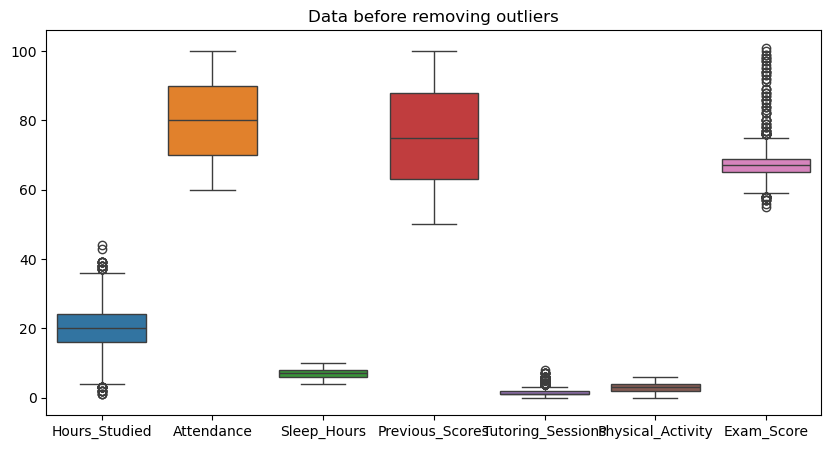

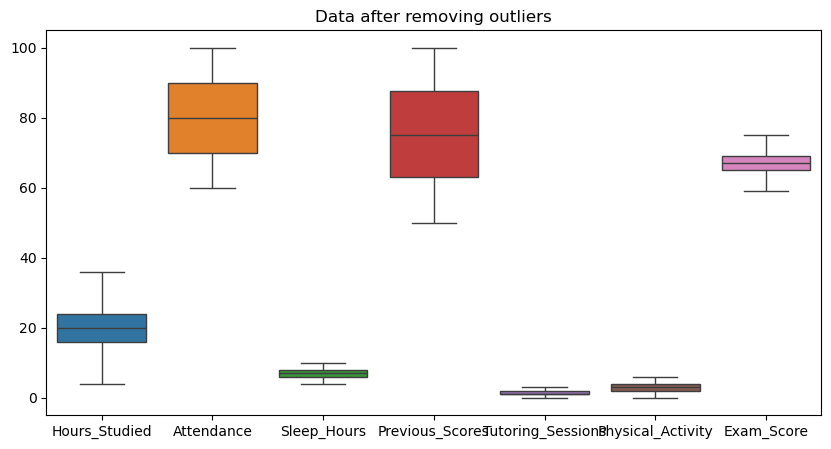

In [186]:
# Outliers

print('Columns with outlier values')
for column in dirty_df.select_dtypes(include=['int64', 'float64']):
    q1 = dirty_df[column].quantile(0.25)
    q3 = dirty_df[column].quantile(0.75)
    iqr = q3 - q1

    upper = q3 + 1.5*iqr
    lower = q1 - 1.5*iqr
    
    mask = (dirty_df[column] > upper) | (dirty_df[column] < lower)
    print(column)
    df = df[~mask]
    
plt.figure(figsize=(10, 5))    
sns.boxplot(data = dirty_df)
plt.title('Data before removing outliers')
plt.show()

plt.figure(figsize=(10, 5))    
sns.boxplot(data = df)
plt.title('Data after removing outliers')
plt.show()

# Phase 3
## Model Planning:



### 1.Statistical summaries

In [188]:
numerical_summary = df.describe() #by defult it will give the statistical summries for the numerical columns

categorical_summary = df.describe(include = 'object')

display(numerical_summary)
display(categorical_summary)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6054.000000,6054.000000,6054.000000,6054.000000,6054.000000,6054.000000,6054.000000
mean,20.019326,79.972580,7.034357,75.111827,1.293360,2.961843,66.981500
std,5.776193,11.498579,1.469827,14.355942,0.983676,1.029563,3.225434
min,4.000000,60.000000,4.000000,50.000000,0.000000,0.000000,59.000000
25%,16.000000,70.000000,6.000000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.000000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.000000,87.750000,2.000000,4.000000,69.000000
max,36.000000,100.000000,10.000000,100.000000,3.000000,6.000000,75.000000


,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6054,6054,6054,6054,6054,6054,6054,6054,6054,6054,6054,6054,6054
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Medium,Medium,Public,Positive,No,High School,Near,Male
freq,3098,3048,3605,3077,5592,2458,3668,4215,2415,5432,3040,3621,3491


### 2.Univariate graphs

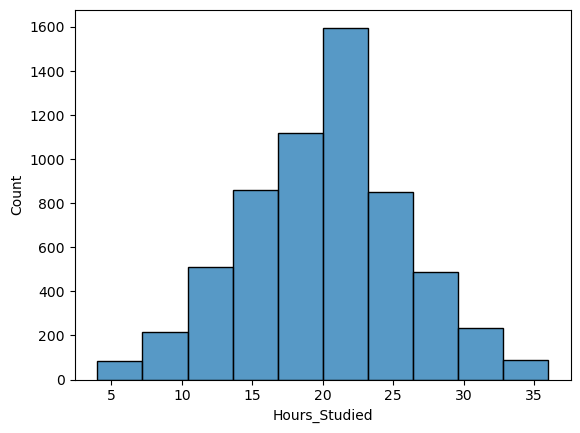

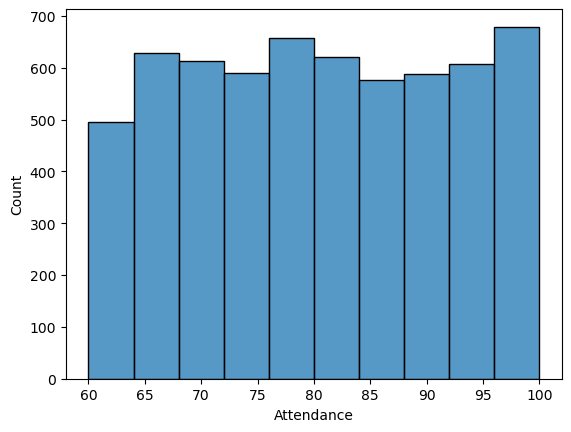

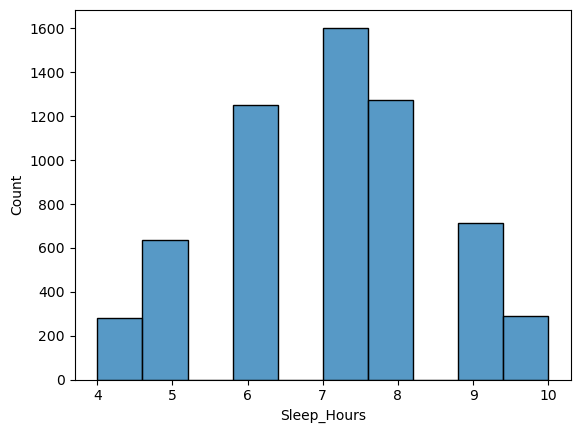

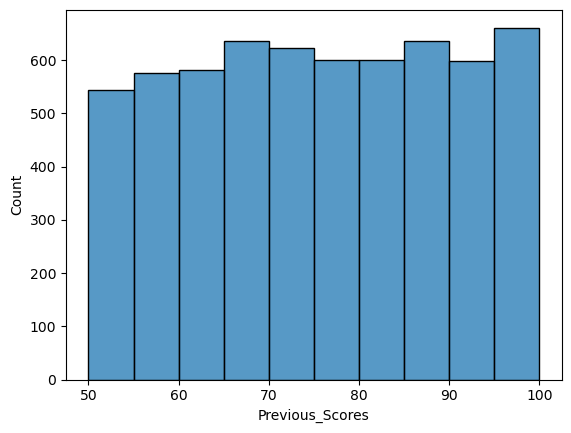

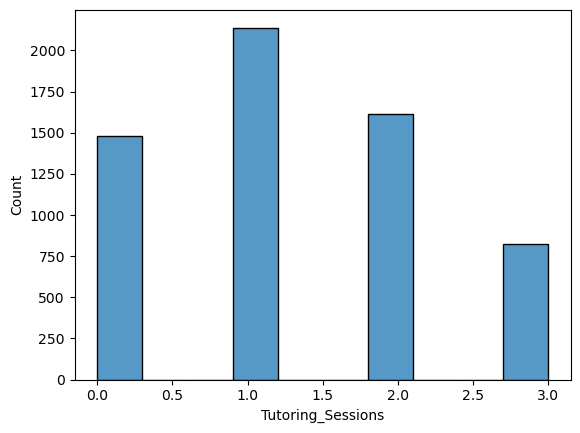

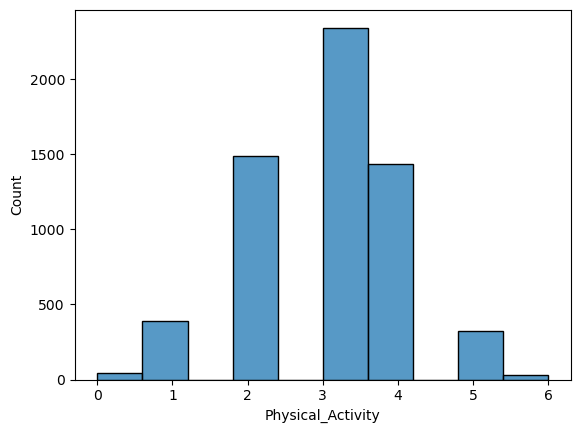

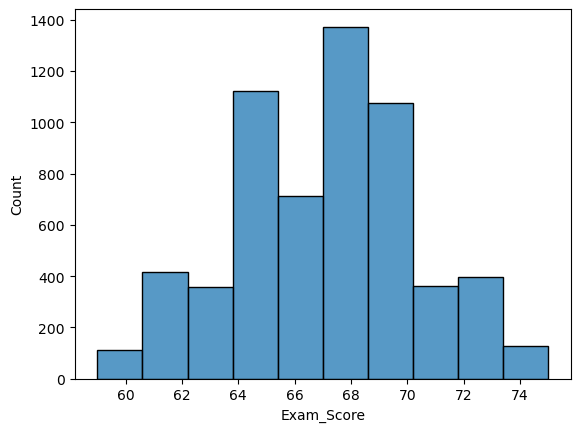

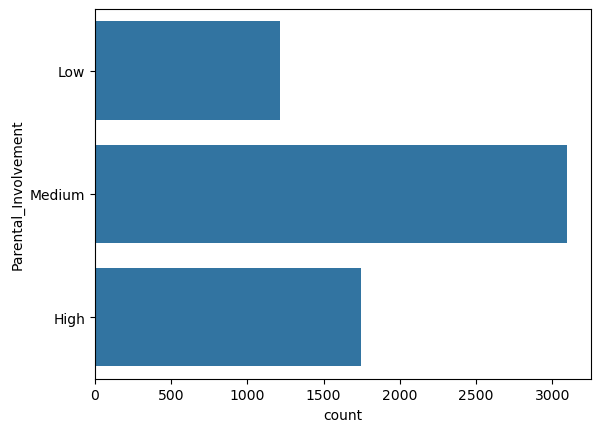

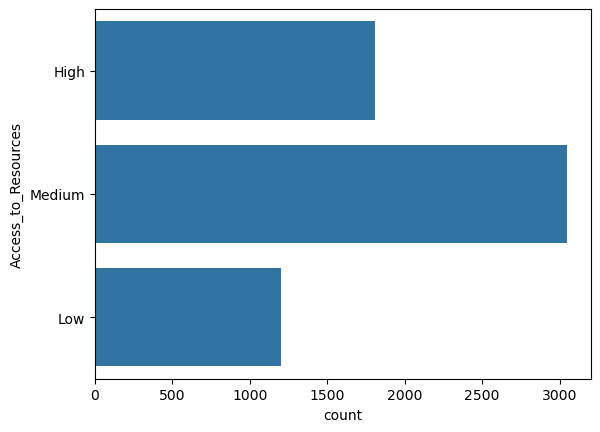

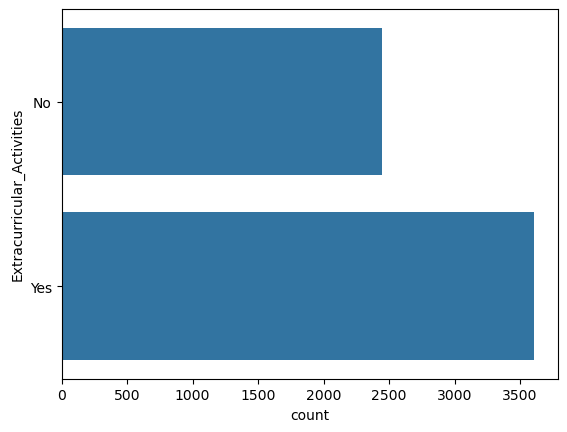

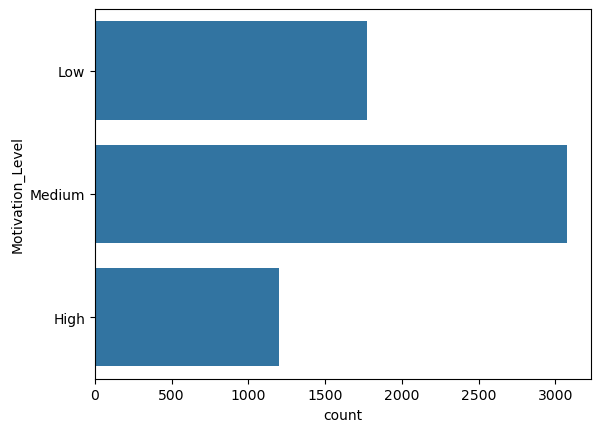

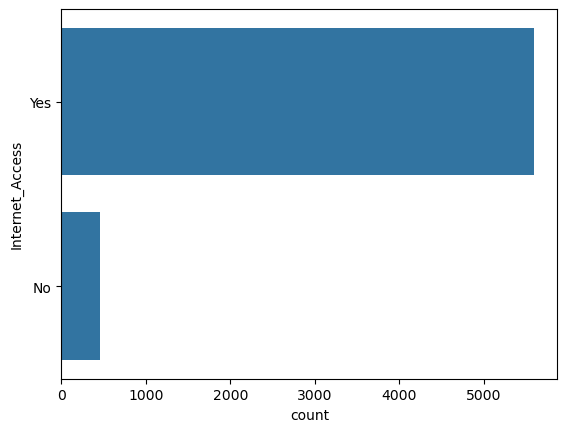

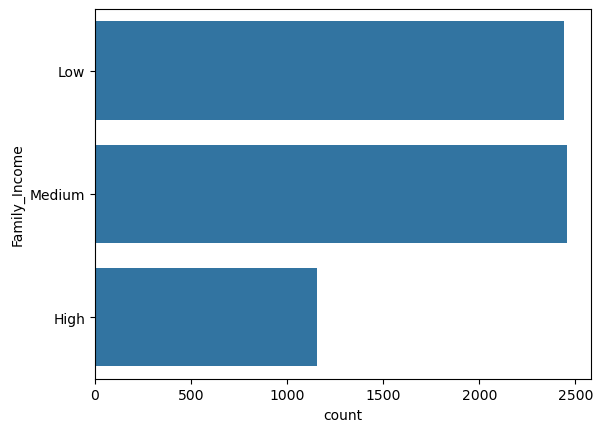

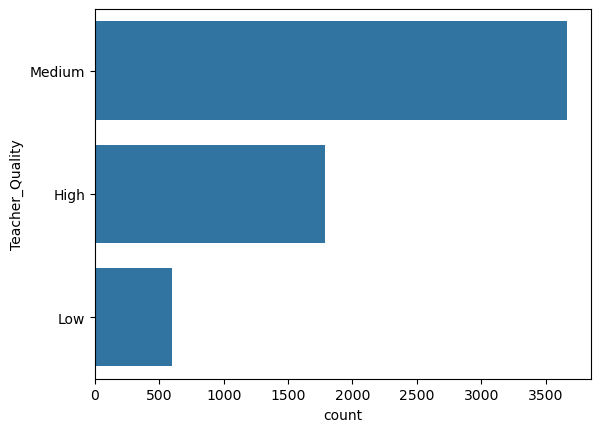

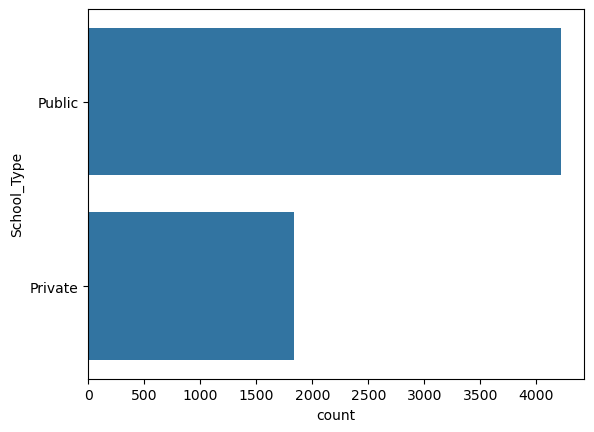

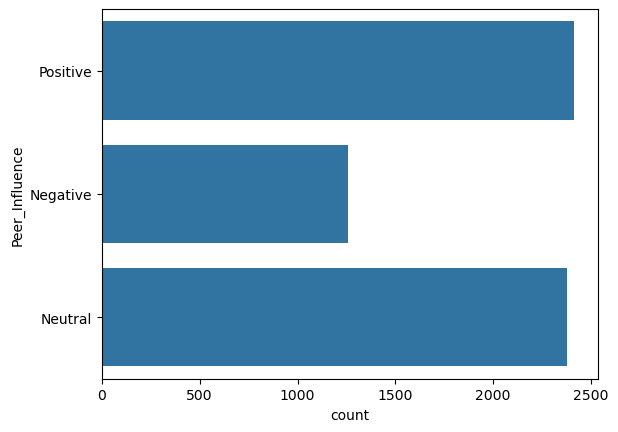

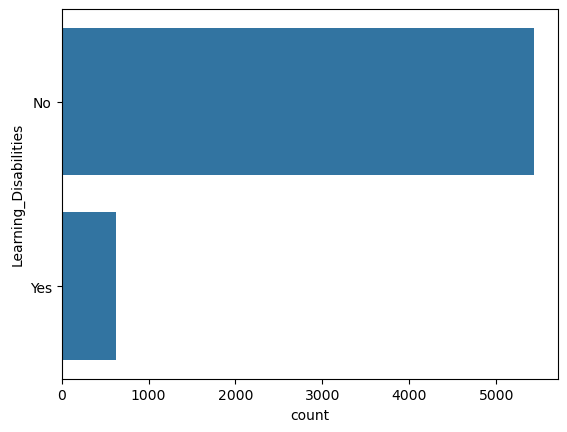

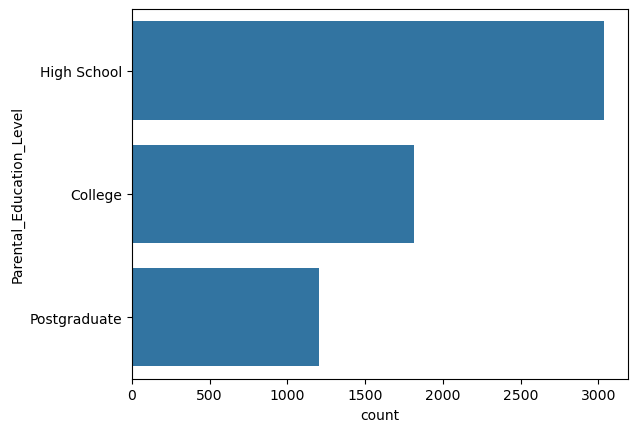

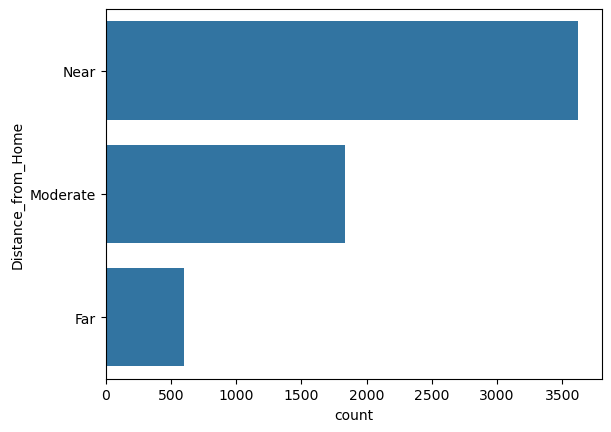

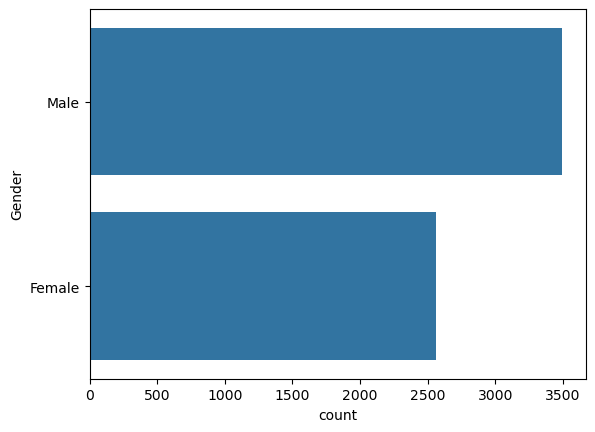

In [190]:
%matplotlib inline

# Identify numeric columns
num_columns = df.select_dtypes(exclude = 'object').columns

#iterateing for each numerical column insted of doing the same procedure for a single variable each time
for i in num_columns:
    plt.figure()
    sns.histplot(x=i,bins=10,data=df)
    plt.show()

# Identify non-numeric columns
obj_columns = df.select_dtypes(include = 'object').columns

# For non-numerical variables both histplot and countplot can be used
for j in obj_columns:
    plt.figure()
#  sns.histplot(y=j,data=df)
    sns.countplot(y=j,data=df)
    plt.show()

### 3. Bivarite plots

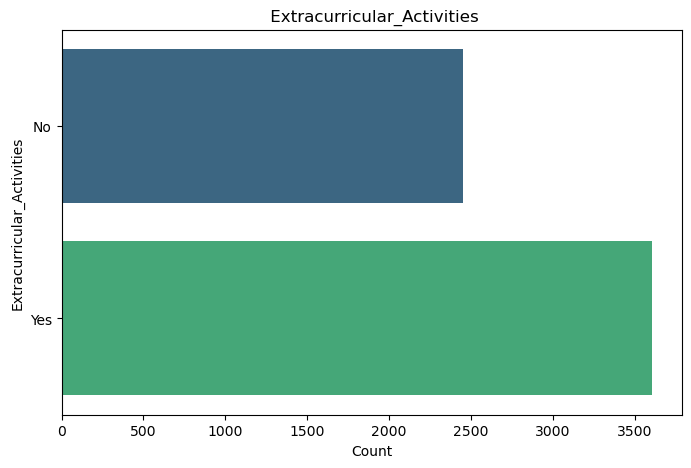

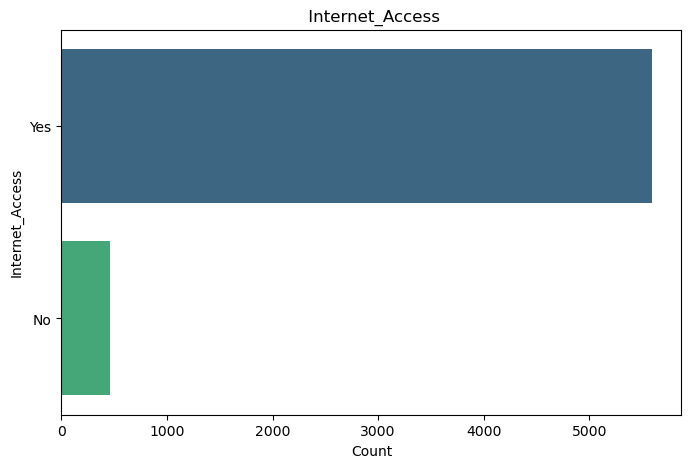

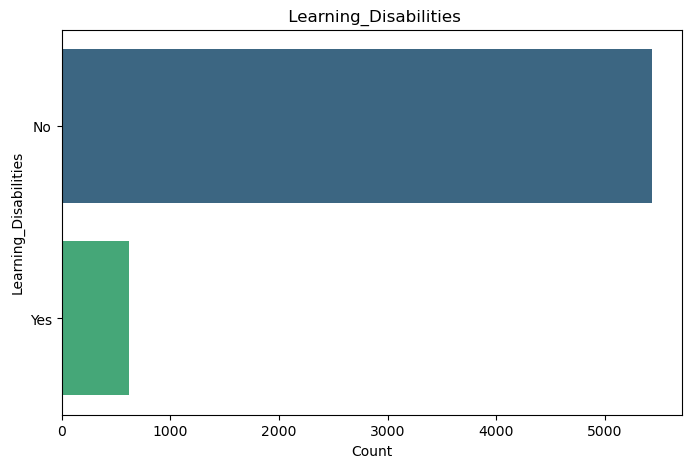

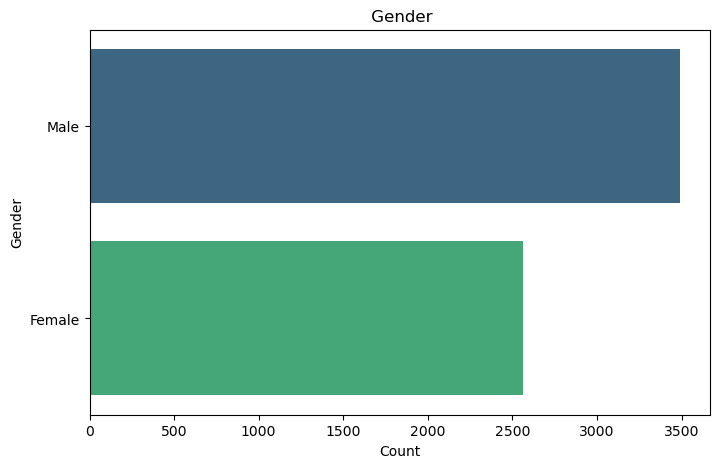

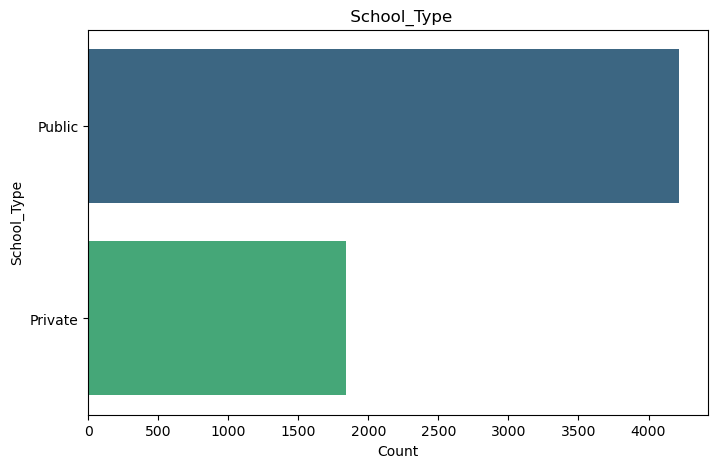

In [192]:
# List of columns with Yes/No values to analyze
binary_columns = ['Extracurricular_Activities', 'Internet_Access', 'Learning_Disabilities',"Gender","School_Type"]

# Generate horizontal bar charts for these columns
for column in binary_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, y=column, palette="viridis")  # Use y=column for horizontal bars
    plt.title(f" {column}")
    plt.xlabel("Count")
    plt.ylabel(column)
    plt.show()

### 4.Advanced graphs

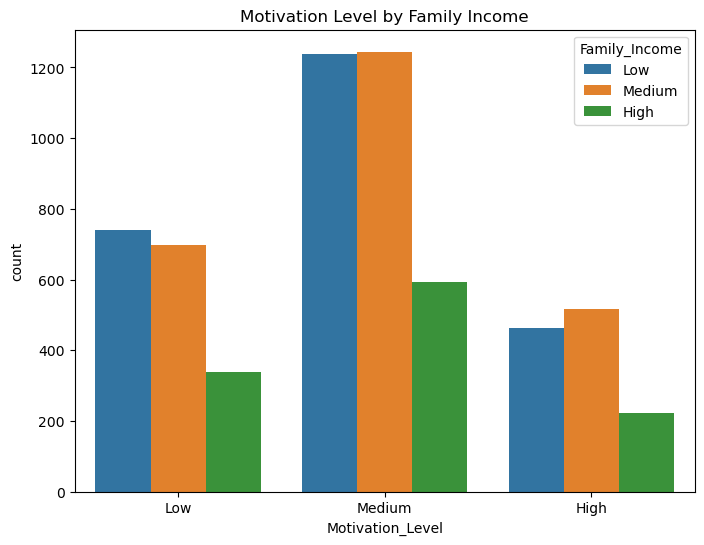

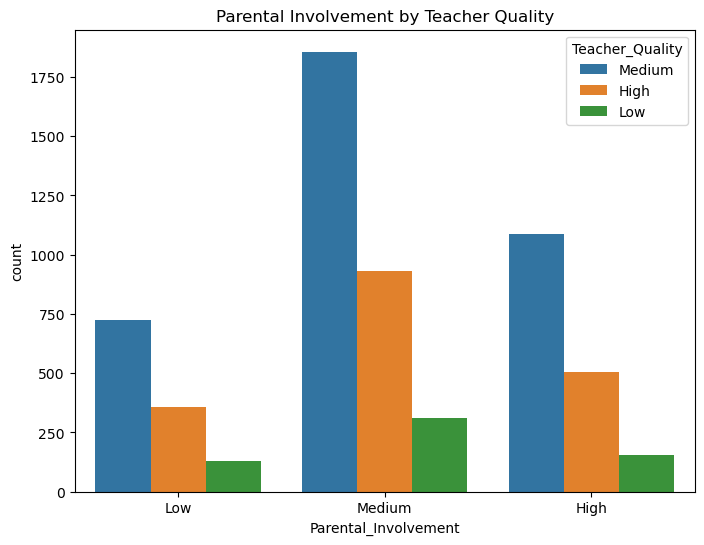

In [194]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Motivation_Level', hue='Family_Income', data=df)
plt.title("Motivation Level by Family Income")
plt.show()

#countplot for Parental Involvement by Teacher Quality
plt.figure(figsize=(8, 6))
sns.countplot(x='Parental_Involvement', hue='Teacher_Quality', data=df)
plt.title("Parental Involvement by Teacher Quality")
plt.show()

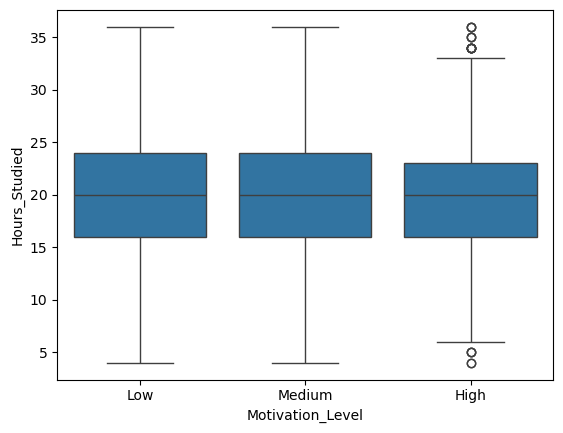

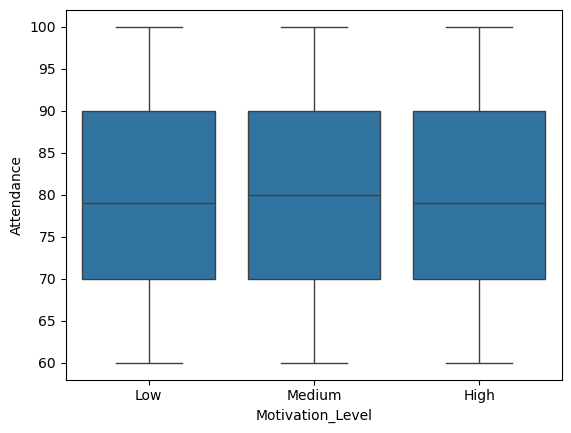

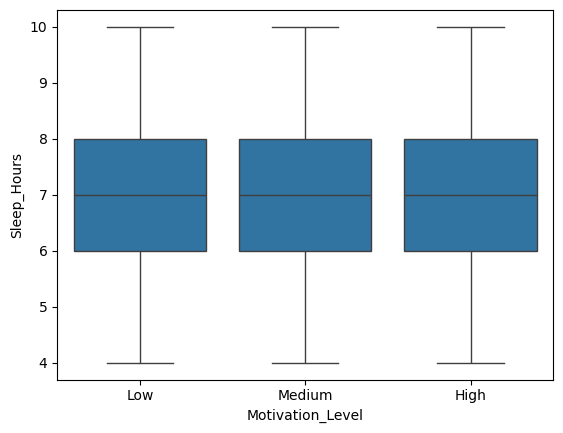

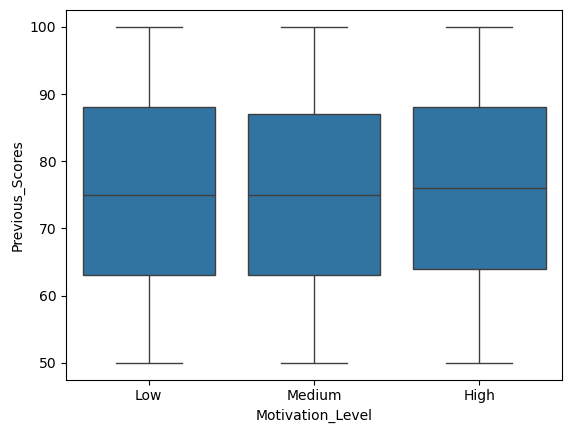

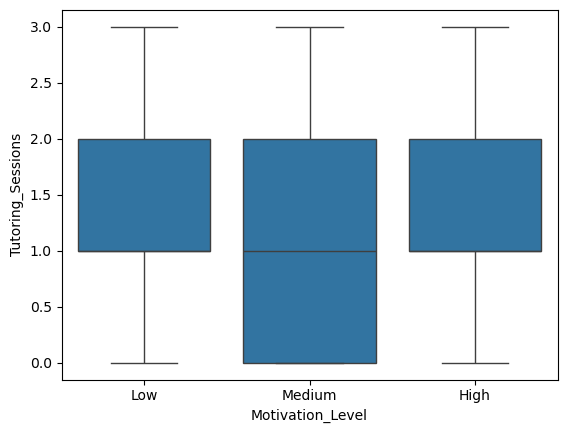

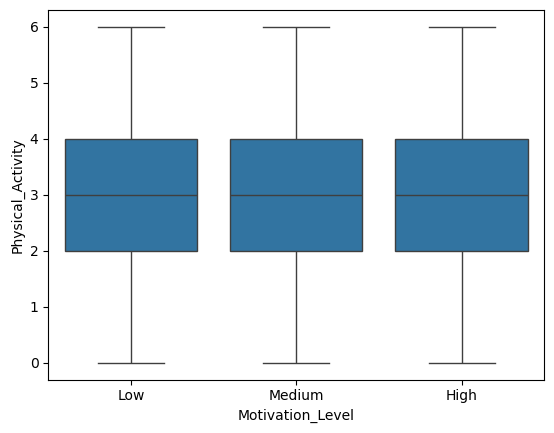

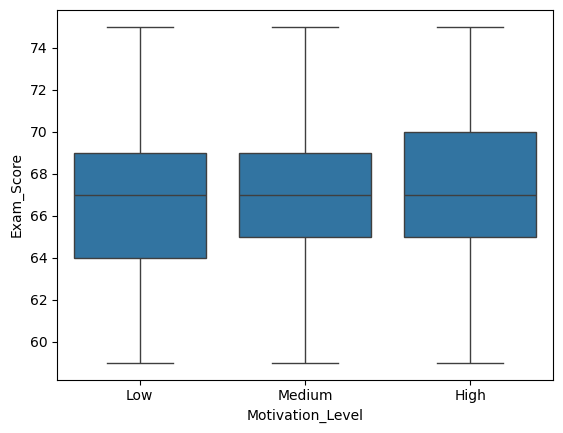

In [195]:
 # boxplot for students performance by Motivation_Level
 num_columns = df.select_dtypes(exclude='object').columns
 for c in num_columns:
    plt.figure()
    sns.boxplot(y=c,x='Motivation_Level',data=df);
    plt.show()

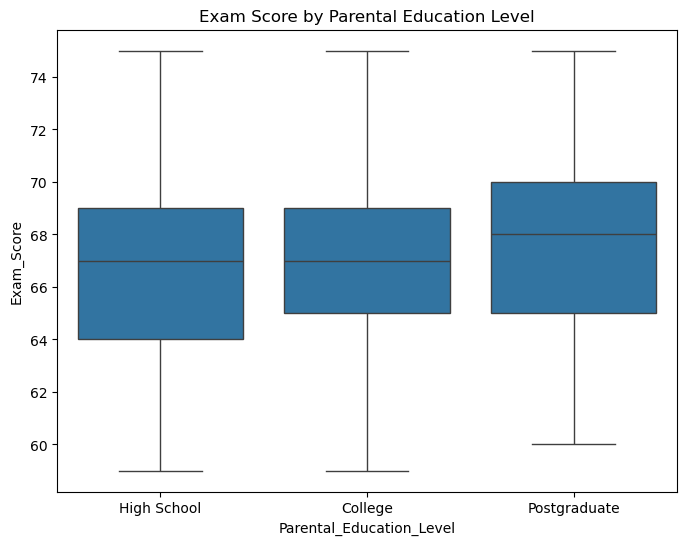

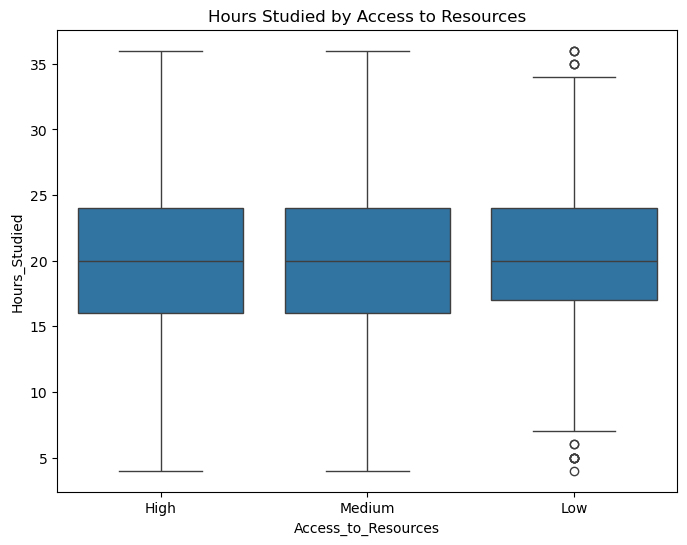

In [196]:
# Boxplot for Exam Score by Parental Education Level
plt.figure(figsize=(8, 6))
sns.boxplot(x='Parental_Education_Level', y='Exam_Score', data=df)
plt.title("Exam Score by Parental Education Level")
plt.show()

# Boxplot for Hours Studied by Access to Resources
plt.figure(figsize=(8, 6))
sns.boxplot(x='Access_to_Resources', y='Hours_Studied', data=df)
plt.title("Hours Studied by Access to Resources")
plt.show()

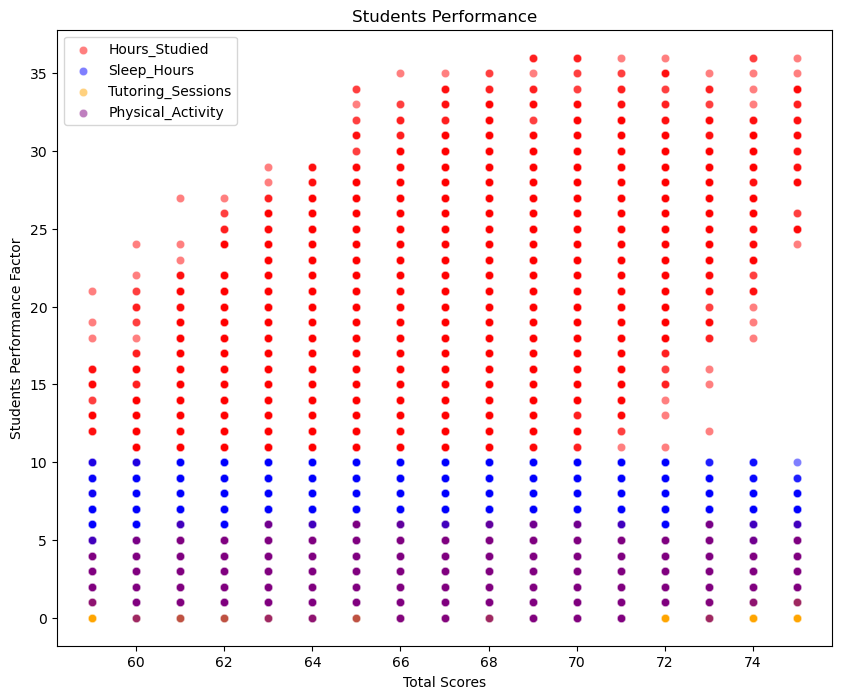

In [197]:
 plt.figure(figsize=(10,8))
 sns.scatterplot(x='Exam_Score', y='Hours_Studied', color='red', label='Hours_Studied',  alpha=0.5, data=df)
 sns.scatterplot(x='Exam_Score', y='Sleep_Hours',color='blue',label='Sleep_Hours', alpha=0.5, data=df)
 #sns.scatterplot(x='Exam_Score', y='Attendance',color='green',label='Attendance', alpha=0.5, data=df)
 sns.scatterplot(x='Exam_Score', y='Tutoring_Sessions',color='orange',label='Tutoring_Sessions', alpha=0.5, data=df)
 #sns.scatterplot(x='Exam_Score', y='Previous_Scores',color='black',label='Previous_Scores', alpha=0.5, data=df)
 sns.scatterplot(x='Exam_Score', y='Physical_Activity',color='purple',label='Physical_Activity', alpha=0.5, data=df)
 plt.ylabel("Students Performance Factor");
 plt.xlabel("Total Scores");
 plt.title("Students Performance");
 plt.show()

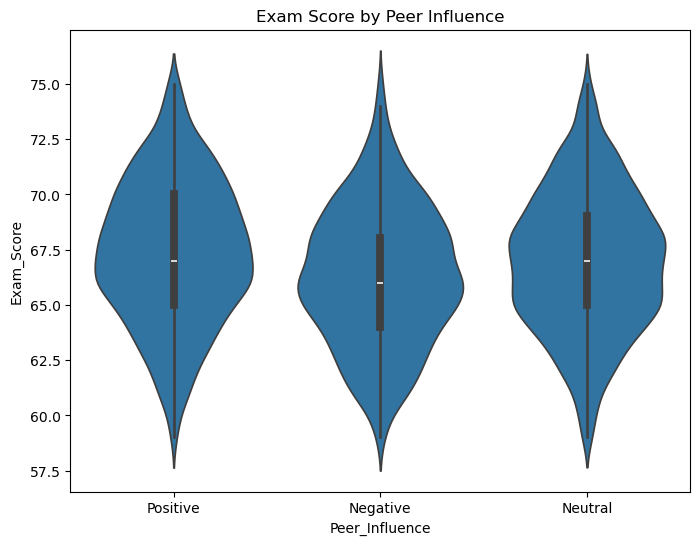

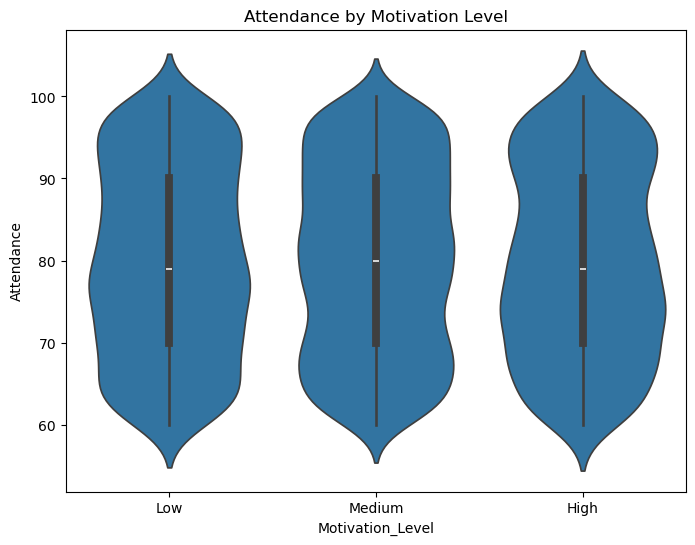

In [198]:
# Violinplot for Exam Score by Peer Influence
plt.figure(figsize=(8, 6))
sns.violinplot(x='Peer_Influence', y='Exam_Score', data=df)
plt.title("Exam Score by Peer Influence")
plt.show()

# Violinplot for Attendance by Motivation Level
plt.figure(figsize=(8, 6))
sns.violinplot(x='Motivation_Level', y='Attendance', data=df)
plt.title("Attendance by Motivation Level")
plt.show()

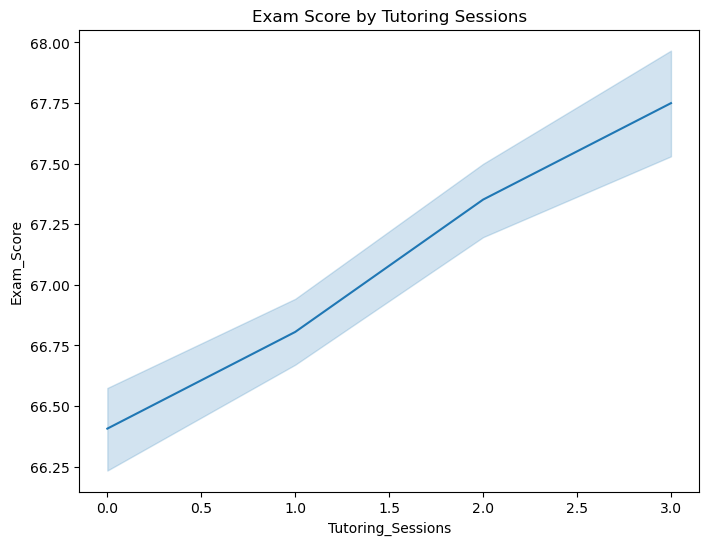

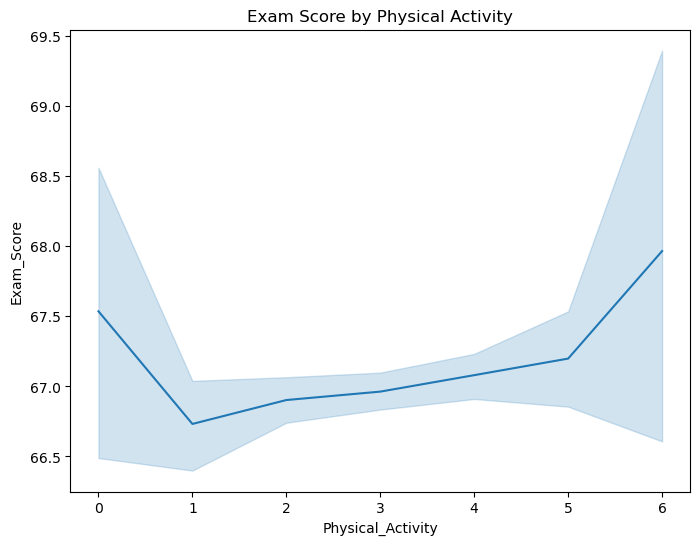

In [199]:
# Lineplot for Tutoring Sessions and Exam Score
plt.figure(figsize=(8, 6))
sns.lineplot(x='Tutoring_Sessions', y='Exam_Score', data=df)
plt.title("Exam Score by Tutoring Sessions")
plt.show()

# Lineplot for Physical Activity and Attendance
plt.figure(figsize=(8, 6))
sns.lineplot(x='Physical_Activity', y='Exam_Score', data=df)
plt.title("Exam Score by Physical Activity")
plt.show()

### 5.The relationships between variables

In [201]:
#assess the relationship between variables
#Caluculate the correlation amoung all the variables
numerical_columns = df.select_dtypes(exclude= "object").columns
correlation_matrix = df[numerical_columns].corr()
styled_corr = correlation_matrix.style.background_gradient(cmap='coolwarm').format(precision=4)
display(styled_corr)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.0000,-0.0307,0.0115,0.0143,-0.0121,-0.0036,0.5008
Attendance,-0.0307,1.0000,-0.0190,-0.0272,0.0060,-0.0317,0.6823
Sleep_Hours,0.0115,-0.0190,1.0000,-0.0184,-0.0053,0.0032,-0.0091
Previous_Scores,0.0143,-0.0272,-0.0184,1.0000,-0.0245,-0.0118,0.1988
Tutoring_Sessions,-0.0121,0.0060,-0.0053,-0.0245,1.0000,-0.0154,0.1410
Physical_Activity,-0.0036,-0.0317,0.0032,-0.0118,-0.0154,1.0000,0.0301
Exam_Score,0.5008,0.6823,-0.0091,0.1988,0.1410,0.0301,1.0000


### 6.Summary of the findings
The database that was provided with contain more than 6607 and 20 columns.  By providing comprehensive details about factors influencing student performance. It includes numerical, categorical, and binary data types, making it suitable for mixed-methods analysis. In this project, all the missing values were extracted. To summarize, these data were used to see the relation between study habits, socioeconomic factors, and performance.